Now we will try to use transfer learning which is a model that was already trained on a huge image dataset and then adapt it to the smaller acne dataset

basically instead of the model learning everything from 0 like we have been doing it will start pre-existing knowledge, such as, edges, colours, textures, curves, shapes, smaller patterns, and surface details

Will try to use MobileNetV2 which is a lightweight pretrained CNN and commonly used for image classification

How it works MNV2 works, it can be seen as two parts, pretrainted feature extractor + custom classifier 

the pretrained part will look at the imnage and extract useful features 

the custom classifier takes those features and predict one of the classes

Need to freeze the base model which is MNV2, and freezing is not updated the pretrained models weights during training, this needs to be done specifically here since MNV2 already learned useful image features so if train everything immediately on the small dataset it might lose those learn features 

In [1]:
from pathlib import Path
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

train_df.head()

,original_path,processed_path,label
0,..\data\raw\acne_scars\scar_026.png,..\data\processed\acne_scars\acne_scars_0026.jpg,acne_scars
1,..\data\raw\comedonal_closed\come_022.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
2,..\data\raw\comedonal_open\comeo_035.png,..\data\processed\comedonal_open\comedonal_ope...,comedonal_open
3,..\data\raw\acne_scars\scar_050.png,..\data\processed\acne_scars\acne_scars_0050.jpg,acne_scars
4,..\data\raw\comedonal_closed\come_021.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed


In [3]:
class_names = sorted(train_df["label"].unique())
label_to_index = {label: index for index, label in enumerate(class_names)}

train_df["label_index"] = train_df["label"].map(label_to_index)
val_df["label_index"] = val_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

class_names, label_to_index

(['acne_scars', 'comedonal_closed', 'comedonal_open', 'inflammatory_acne'],
 {'acne_scars': 0,
  'comedonal_closed': 1,
  'comedonal_open': 2,
  'inflammatory_acne': 3})

In [4]:
train_paths = train_df["processed_path"].values
val_paths = val_df["processed_path"].values
test_paths = test_df["processed_path"].values

train_labels = train_df["label_index"].values
val_labels = val_df["label_index"].values
test_labels = test_df["label_index"].values

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image_for_mobilenet(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [6]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_ds = train_ds.map(load_image_for_mobilenet)
val_ds = val_ds.map(load_image_for_mobilenet)
test_ds = test_ds.map(load_image_for_mobilenet)

train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [7]:
## still going to use the gentle data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
])

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [9]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.2394 - loss: 2.3475 - val_accuracy: 0.1935 - val_loss: 1.9866
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.2958 - loss: 2.0215 - val_accuracy: 0.1613 - val_loss: 1.8021
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.2535 - loss: 1.9449 - val_accuracy: 0.1613 - val_loss: 1.6786
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.2887 - loss: 1.7385 - val_accuracy: 0.1935 - val_loss: 1.5962
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.3239 - loss: 1.5853 - val_accuracy: 0.1613 - val_loss: 1.5413
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.3380 - loss: 1.5273 - val_accuracy: 0.1935 - val_loss: 1.4963
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.2817 - loss: 1.5797 - val_accuracy: 0.2258 - val_loss: 1.4530
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.3803 - loss: 1.3538 - val_accuracy: 0.2581 - v

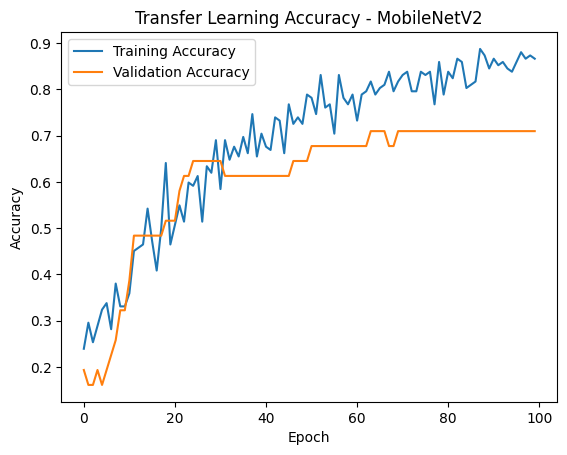

In [13]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Transfer Learning Accuracy - MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

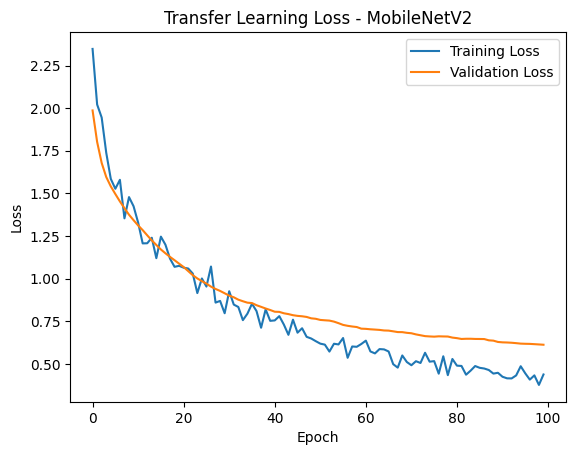

In [14]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Transfer Learning Loss - MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()